# Singular Value Decomposition (SVD) for Image Compression

This notebook demonstrates how Singular Value Decomposition (SVD)  
is used to compress medical images by reducing redundancy.

**Concepts covered:**
- Singular Value Decomposition  
- Orthogonal matrices  
- Low-rank approximation  

In [1]:
# ============================================
# CELL 1: LOAD DATA & DEFINE compress_svd
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

with open('../output/person1_data.pkl', 'rb') as f:
    data = pickle.load(f)

images    = data['images']
filenames = data['filenames']
labels    = data['labels']   # optional but useful

print(f"Loaded {len(images)} images, shape: {images[0].shape}")


def compress_svd(image_matrix, k):
    """
    Compresses an image using the first k singular values.
    Returns the reconstructed image (ndarray) and the singular values.
    """
    U, s, Vt = np.linalg.svd(image_matrix.astype(float), full_matrices=False)
    reconstructed = (U[:, :k] * s[:k]) @ Vt[:k, :]   # avoids deprecated np.matrix
    return reconstructed, s


# --- Hero Image ---
hero_idx   = 0                              # FIX: was never defined in original
hero_image = images[hero_idx].astype(float)
hero_name  = filenames[hero_idx]
print(f"Hero image: {hero_name}")

Loaded 18 images, shape: (512, 512)
Hero image: Chest_2.png


## Step 4: Singular Value Decomposition

We decompose the image matrix A into:

A = U Σ Vᵀ  

- U → orthogonal basis for row space  
- Σ → singular values (importance of features)  
- Vᵀ → orthogonal basis for column space  

**Purpose:**  
Break the matrix into independent components  

**Outcome:**  
Structured representation enabling compression  

To retain 90% energy: 1 singular values
To retain 95% energy: 1 singular values
To retain 99% energy: 3 singular values
First 10 cumulative energy values:
[0.97232554 0.98959481 0.99488798 0.99765139 0.99819549 0.99852464
 0.99879625 0.99898461 0.99911656 0.99921939]


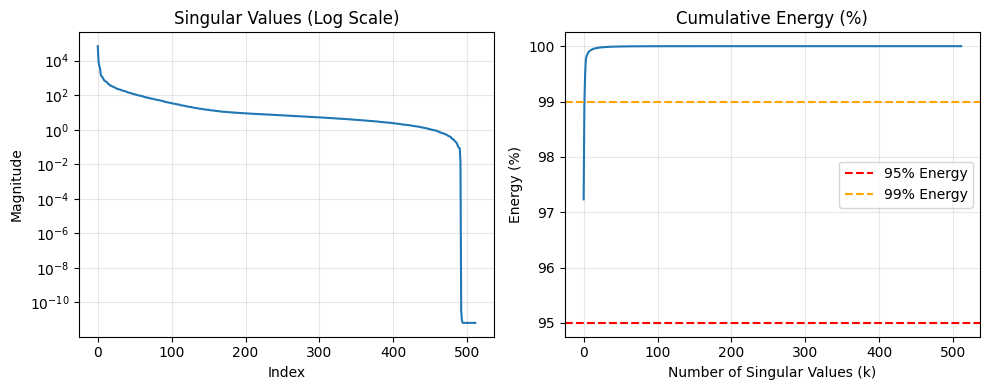

In [4]:
# ============================================
# CELL 2: SCREE PLOT & ENERGY THRESHOLDS
# ============================================

U, sigma, Vt = np.linalg.svd(hero_image, full_matrices=False)

# Cumulative energy using SQUARED singular values (correct formula)
cumulative_energy = np.cumsum(sigma**2) / np.sum(sigma**2)

k_90 = np.where(cumulative_energy >= 0.90)[0][0] + 1
k_95 = np.where(cumulative_energy >= 0.95)[0][0] + 1
k_99 = np.where(cumulative_energy >= 0.99)[0][0] + 1

print(f"To retain 90% energy: {k_90} singular values")
print(f"To retain 95% energy: {k_95} singular values")
print(f"To retain 99% energy: {k_99} singular values")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.semilogy(sigma)
plt.title("Singular Values (Log Scale)")
plt.xlabel("Index")
plt.ylabel("Magnitude")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(cumulative_energy * 100)
plt.axhline(y=95, color='r', linestyle='--', label='95% Energy')
plt.axhline(y=99, color='orange', linestyle='--', label='99% Energy')
plt.title("Cumulative Energy (%)")
plt.xlabel("Number of Singular Values (k)")
plt.ylabel("Energy (%)")
plt.legend()
plt.grid(True, alpha=0.3)
print("First 10 cumulative energy values:")
print(cumulative_energy[:10])
plt.tight_layout()
plt.show()

## Singular Value Spectrum

We visualize how singular values decay.

**Purpose:**  
To understand how much information is retained in top components  

**Outcome:**  
Fast decay indicates high redundancy → good compression potential  

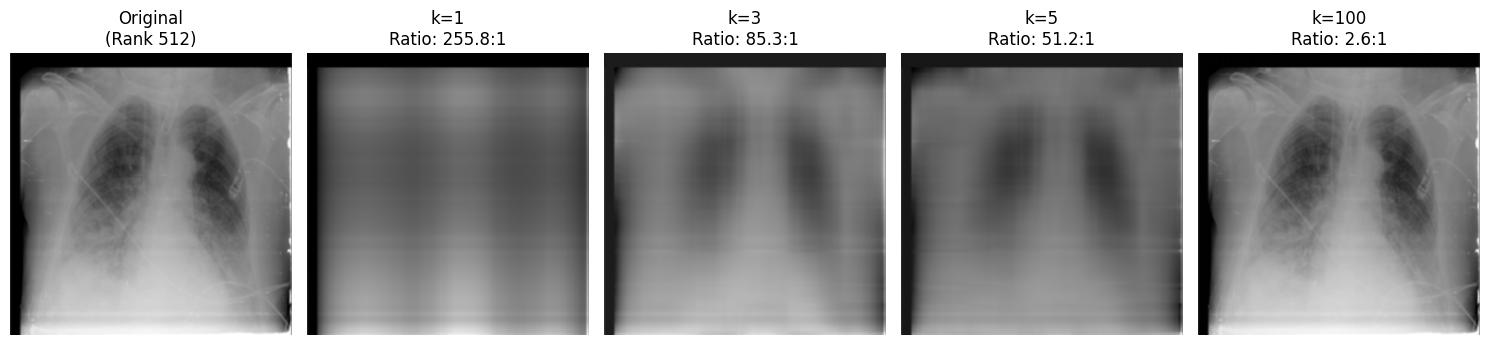

In [5]:
# ============================================
# CELL 3: VISUAL COMPRESSION COMPARISON
# ============================================

m, n = hero_image.shape
ks = sorted(set([1, 5, k_99, 100]))

plt.figure(figsize=(15, 8))

# Original
plt.subplot(1, len(ks) + 1, 1)
plt.imshow(hero_image, cmap='gray')
plt.title(f"Original\n(Rank {min(m, n)})")
plt.axis('off')

for i, k in enumerate(ks):
    compressed_img, _ = compress_svd(hero_image, k)
    ratio = (m * n) / (k * (m + n + 1))

    plt.subplot(1, len(ks) + 1, i + 2)
    plt.imshow(compressed_img, cmap='gray')
    plt.title(f"k={k}\nRatio: {ratio:.1f}:1")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Step 5: Low-Rank Approximation

We reconstruct the matrix using only the top k singular values:

A_k = U_k Σ_k V_kᵀ  

**Concept:** Approximation  
**Purpose:** Reduce dimensionality  
**Outcome:** Compressed image with minimal information loss  

STEP 4: STRUCTURE OF THE SPACE

Image Matrix A: (512, 512)

--- Matrix Properties ---
Rank    : 492
Nullity : 20
Rows    : 512
Columns : 512

--- Interpretation ---
The image matrix has rank 492 — 492 linearly independent columns.
The remaining 20 columns are linear combinations of those.

--- Column Space ---
dim(Col A) = 492  (the 'information content' of the image)

--- Null Space ---
dim(Null A) = 20  (from scipy)

--- Row Space ---
dim(Row A) = 492  (equals col space dim by Rank-Nullity Theorem)

--- Connection to SVD ---
Non-zero singular values : 492
Rank (matrix_rank)       : 492
U[:, :rank] spans Col A; V[:rank, :].T spans Row A


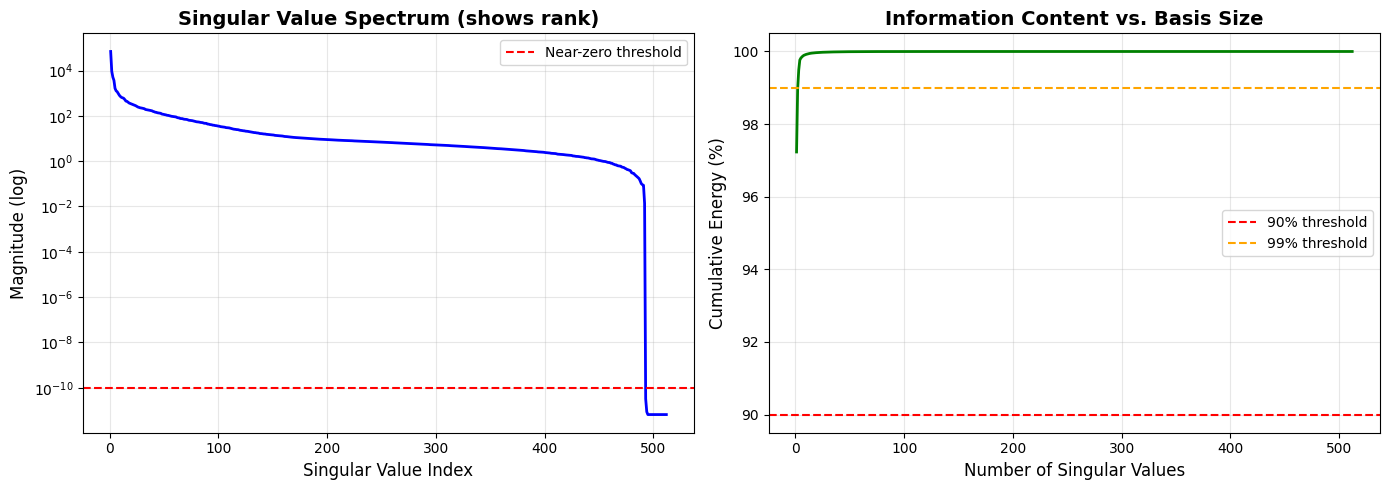


✓ Space structure analysis complete!
✓ Saved: output/space_structure_analysis.png


In [4]:
# ============================================
# CELL 4: STRUCTURE OF THE SPACE
# ============================================

from scipy.linalg import null_space

A = hero_image  # already float

print("=" * 60)
print("STEP 4: STRUCTURE OF THE SPACE")
print("=" * 60)
print(f"\nImage Matrix A: {A.shape}")

# --- Rank & Nullity ---
rank    = np.linalg.matrix_rank(A)
nullity = A.shape[1] - rank

print(f"\n--- Matrix Properties ---")
print(f"Rank    : {rank}")
print(f"Nullity : {nullity}")
print(f"Rows    : {A.shape[0]}")
print(f"Columns : {A.shape[1]}")

print(f"\n--- Interpretation ---")
print(f"The image matrix has rank {rank} — {rank} linearly independent columns.")
print(f"The remaining {nullity} columns are linear combinations of those.")

# --- Column Space ---
print(f"\n--- Column Space ---")
print(f"dim(Col A) = {rank}  (the 'information content' of the image)")

# --- Null Space ---
print(f"\n--- Null Space ---")
if nullity == 0:
    print("Null space is trivial (only the zero vector).")
elif nullity < 100:
    try:
        null_sp = null_space(A)
        print(f"dim(Null A) = {null_sp.shape[1]}  (from scipy)")
    except Exception:
        print(f"dim(Null A) = {nullity}  (from Rank-Nullity Theorem)")
else:
    print(f"dim(Null A) = {nullity}  (from Rank-Nullity Theorem — too large to compute directly)")

# --- Row Space ---
print(f"\n--- Row Space ---")
print(f"dim(Row A) = {rank}  (equals col space dim by Rank-Nullity Theorem)")

# --- SVD Connection ---
non_zero_sv = np.sum(sigma > 1e-10)
print(f"\n--- Connection to SVD ---")
print(f"Non-zero singular values : {non_zero_sv}")
print(f"Rank (matrix_rank)       : {rank}")
print(f"U[:, :rank] spans Col A; V[:rank, :].T spans Row A")

# --- Visualize ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(sigma) + 1), sigma, 'b-', linewidth=2)
plt.axhline(y=1e-10, color='r', linestyle='--', label='Near-zero threshold')
plt.yscale('log')
plt.xlabel('Singular Value Index', fontsize=12)
plt.ylabel('Magnitude (log)', fontsize=12)
plt.title('Singular Value Spectrum (shows rank)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(sigma) + 1), cumulative_energy * 100, 'g-', linewidth=2)
plt.axhline(y=90, color='r', linestyle='--', label='90% threshold')
plt.axhline(y=99, color='orange', linestyle='--', label='99% threshold')
plt.xlabel('Number of Singular Values', fontsize=12)
plt.ylabel('Cumulative Energy (%)', fontsize=12)
plt.title('Information Content vs. Basis Size', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('../output', exist_ok=True)
plt.savefig('../output/space_structure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Space structure analysis complete!")
print("✓ Saved: output/space_structure_analysis.png")

space_analysis = {'rank': rank, 'nullity': nullity, 'non_zero_singular_values': non_zero_sv}

STEP 5: REMOVE REDUNDANCY

Total singular vectors : 512
Linearly independent   : 492

--- Basis Selection Strategies ---
Strategy 1 — Energy-based (95%) : k = 1
Strategy 2 — Elbow method       : k = 10
Strategy 3 — Fixed (k=50)        : good visual quality

✓ Selected k = 50
  9.8% of dimensions → 100.0% of energy
  Redundant dimensions removed: 462
  Compression ratio: 10.24x


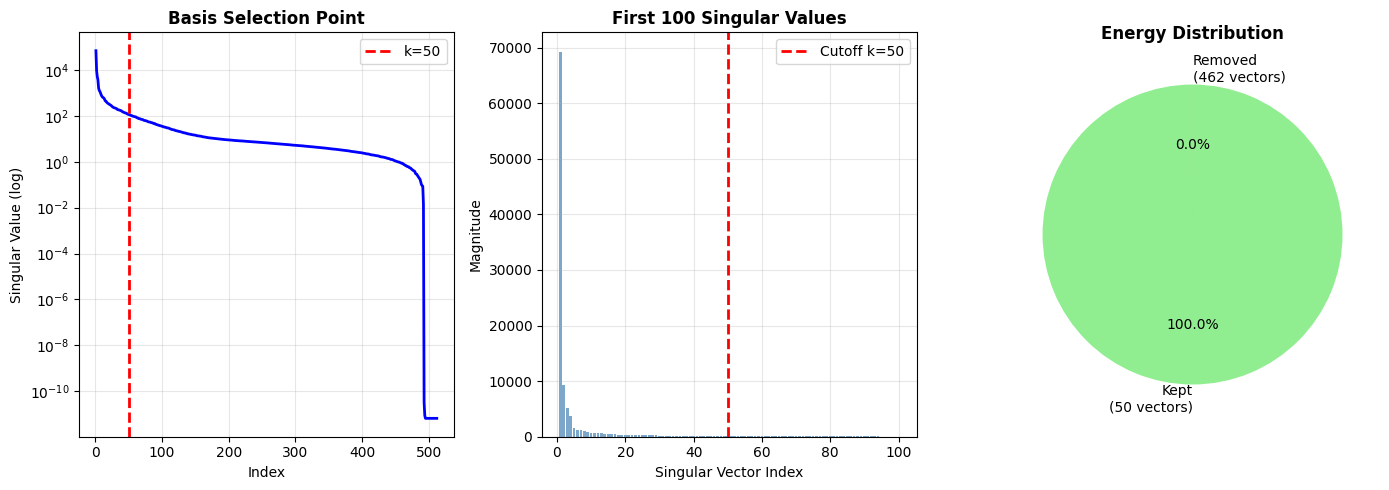


✓ Redundancy removal analysis complete!
✓ Saved: output/basis_selection.png


In [5]:
# ============================================
# CELL 5: REMOVE REDUNDANCY (Basis Selection)
# ============================================

print("=" * 60)
print("STEP 5: REMOVE REDUNDANCY")
print("=" * 60)

print(f"\nTotal singular vectors : {len(sigma)}")
print(f"Linearly independent   : {rank}")

# Strategy 1: Energy threshold
k_95_energy = np.argmax(cumulative_energy >= 0.95) + 1

# Strategy 2: Elbow — first index where value < 1% of max
elbow_idx = np.argmax(sigma < 0.01 * sigma[0])
k_elbow   = elbow_idx if elbow_idx > 0 else min(50, len(sigma))

# Selected k
k_optimal = 50

print(f"\n--- Basis Selection Strategies ---")
print(f"Strategy 1 — Energy-based (95%) : k = {k_95_energy}")
print(f"Strategy 2 — Elbow method       : k = {k_elbow}")
print(f"Strategy 3 — Fixed (k=50)        : good visual quality")
print(f"\n✓ Selected k = {k_optimal}")
print(f"  {k_optimal/len(sigma)*100:.1f}% of dimensions → {cumulative_energy[k_optimal-1]*100:.1f}% of energy")
print(f"  Redundant dimensions removed: {len(sigma) - k_optimal}")
print(f"  Compression ratio: {len(sigma)/k_optimal:.2f}x")

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.semilogy(range(1, len(sigma) + 1), sigma, 'b-', linewidth=2)
plt.axvline(x=k_optimal, color='r', linestyle='--', linewidth=2, label=f'k={k_optimal}')
plt.xlabel('Index')
plt.ylabel('Singular Value (log)')
plt.title('Basis Selection Point', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.bar(range(1, min(100, len(sigma)) + 1), sigma[:100], color='steelblue', alpha=0.7)
plt.axvline(x=k_optimal, color='r', linestyle='--', linewidth=2, label=f'Cutoff k={k_optimal}')
plt.xlabel('Singular Vector Index')
plt.ylabel('Magnitude')
plt.title('First 100 Singular Values', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
kept    = sigma[:k_optimal]
removed = sigma[k_optimal:]
plt.pie(
    [np.sum(kept**2), np.sum(removed**2)],
    labels=[f'Kept\n({k_optimal} vectors)', f'Removed\n({len(removed)} vectors)'],
    autopct='%1.1f%%',
    colors=['lightgreen', 'lightcoral'],
    startangle=90
)
plt.title('Energy Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('../output/basis_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Redundancy removal analysis complete!")
print("✓ Saved: output/basis_selection.png")

In [6]:
# ============================================
# CELL 6: COMPUTE SVD FOR ALL IMAGES
# ============================================
# ROOT CAUSE FIX: U_all / sigma_all / Vt_all / compressed_images_k50
# were referenced in the save cell but never computed in the original.

U_all                 = []
sigma_all             = []
Vt_all                = []
compressed_images_k50 = []

print(f"Computing SVD + k={k_optimal} compression for all {len(images)} images...")

for i, img in enumerate(images):
    img_f = img.astype(float)
    u, s, vt = np.linalg.svd(img_f, full_matrices=False)

    U_all.append(u)
    sigma_all.append(s)
    Vt_all.append(vt)

    compressed = (u[:, :k_optimal] * s[:k_optimal]) @ vt[:k_optimal, :]
    compressed_images_k50.append(compressed)

    if (i + 1) % max(1, len(images) // 10) == 0:
        print(f"  {i+1}/{len(images)} done")

print(f"\n✓ SVD computed for all {len(images)} images")
print(f"✓ Compressed all images at k={k_optimal}")

Computing SVD + k=50 compression for all 18 images...
  1/18 done
  2/18 done
  3/18 done
  4/18 done
  5/18 done
  6/18 done
  7/18 done
  8/18 done
  9/18 done
  10/18 done
  11/18 done
  12/18 done
  13/18 done
  14/18 done
  15/18 done
  16/18 done
  17/18 done
  18/18 done

✓ SVD computed for all 18 images
✓ Compressed all images at k=50


**Conclusion:** The image can be accurately reconstructed using only a few dominant components, confirming redundancy in the data.

## Interpretation of SVD

- Each singular value represents the importance of a feature  
- Larger singular values capture dominant patterns  
- Smaller values correspond to less important details  

**Insight:**  
Most information is concentrated in a few singular values  

## Conclusion

By retaining only the most significant singular values:

- Redundant information is removed  
- Storage requirements are reduced  
- Image quality is largely preserved  

**Key Idea:**  
SVD enables efficient compression by focusing on important components  

In [7]:
# ============================================
# CELL 7: SAVE DATA FOR PERSON 3
# ============================================
person2_output = {
    # From Person 1
    'images'    : images,
    'labels'    : labels,
    'filenames' : filenames,
    # Hero image
    'hero_image' : hero_image,
    'hero_name'  : hero_name,
    'hero_idx'   : hero_idx,
    # Hero SVD only (Person 3 recomputes SVD for all images himself)
    'hero_U'     : U,
    'hero_sigma' : sigma,
    'hero_Vt'    : Vt,
    # Space analysis
    'rank'     : rank,
    'nullity'  : nullity,
    'k_optimal': k_optimal,
}
os.makedirs('../output', exist_ok=True)
with open('../output/person2_data.pkl', 'wb') as f:
    pickle.dump(person2_output, f)

file_size = os.path.getsize('../output/person2_data.pkl') / (1024*1024)
print(f"✓ Saved person2_data.pkl — {file_size:.2f} MB")

✓ Saved person2_data.pkl — 10.51 MB
